In [7]:
# import stuff
import asymmetree.treeevolve as te
import networkx as nx
import matplotlib.pyplot as plt
import random
import numpy as np
import MISC_Functions
import copy

from asymmetree.visualization.tree_vis import visualize, assign_colors
from networkx.drawing.nx_pydot import graphviz_layout
from bmg_Tony import bmg
from bmg_fun import convert_to_nx
from bmg_fun import thinness_graph
from insert_hybrid import insertHybrid, insertHybrid2
from BCEA import BCEA
from BCEA import BCEA
from BICcherry_reverse import BICcherry_reverse
from lrt_fun import lrt_from_bmg
from BICcherryRestrict import BICcherryRestrict
from simplifying_operations import greedy_search

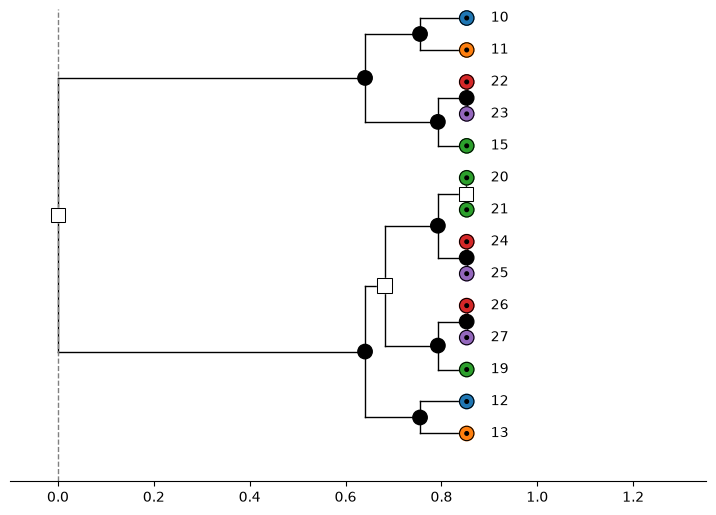

In [2]:
speciesTree, geneTree = MISC_Functions.generateTree(seed = 1,nSpecies = 5)
# Gute Kombinationen:
# (43,2), (1,5)
# get color dicts
species_colors, gene_colors = assign_colors(speciesTree, geneTree)
# visualize asymetree tree
visualize(geneTree, color_dict=gene_colors)

# convert to networkx
Tree = convert_to_nx(geneTree)

# Original BMG:
gene_colors_str = {str(k): v for k, v in gene_colors.items()}
#BMG, gene_colors = thinness_graph(bmg(Tree), gene_colors_str)
BMG = bmg(Tree)
BC = BICcherry_reverse(BMG)
BMGBC = bmg(BC)

if not nx.utils.graphs_equal(BMG, BMGBC):
    print("the BMG already breaks for the Tree")

In [2]:
"""
Konsolidierter Code fuer die Untersuchung, wann ein einzelner eingefuegter
Hybrid im Netzwerk dazu fuehrt, dass BMG(Network) != BMG(BCEA(BMG)).

Enthaelt:
  - check_hybrid_criteria(...): Kriterien-Pruefung (Suche nach BMG Chains)
  - der Haupt-Loop mit Ereignis-Sammlung (events, anomalies, false_positives)
  - Plot-Funktionen fuer Netzwerk + BMG nebeneinander

Voraussetzung: MISC_Functions, convert_to_nx(...), bmg(...),
thinness_graph(...), BICcherry_reverse(...), insertHybrid2(...)
sind bereits an anderer Stelle im Notebook definiert.
"""

# =====================================================================
# 1. Kriterien-Pruefung
# =====================================================================


def check_criteria(BMG: nx.DiGraph):
    """
    Prueft, ob BMG mindestens eine "Kette" fehlender/asymmetrischer Best
    Matches enthaelt, die der (einstufige) BIC-Cherry-Expansion-Algorithmus
    (BCEA) -- mit reziprozitaets-bevorzugter Kandidatenwahl -- unter der
    weak-Definition nicht korrekt darstellen kann.
 
    Formale Kriterium
    ------------------
    Mit N(x) = {y : (x,y) in E(BMG)} (echte Best Matches von x) und
    L_c = {v in V : sigma(v) = c} (alle Gene der Farbe c):
 
    BMG ist NICHT durch den (einstufigen) BCEA darstellbar genau dann, wenn
 
        exists x in V, exists Farbe c != sigma(x):
            N(x) ∩ L_c  ⊊  L_c                     (x deckt c nicht vollstaendig ab)
            und  fuer alle z in N(x) ∩ L_c:  (z,x) not in E    (KEIN Kandidat reziprok)
 
    Kurz: x braucht eine Korrektur bzgl. Farbe c (mind. ein Gen dieser
    Farbe fehlt x als Match), UND unter x's tatsaechlichen Matches dieser
    Farbe ist KEIN EINZIGER reziprok. Weil die Kandidatenwahl im BCEA
    reziproke Kandidaten bevorzugt (siehe insertNode/findCandidate), reicht
    schon EIN reziproker Kandidat aus, um den Bruch zu vermeiden -- daher
    "fuer alle" statt (wie in einer frueheren Version) "es existiert einer".
 
    Deckt x eine Farbe schon vollstaendig ab, bleibt die urspruengliche
    P-Cherry ohnehin unangetastet -- daher zaehlt das nicht als Bruchgrund,
    selbst wenn dort asymmetrische Matches vorkommen.
 
    Parameters
    ----------
    BMG : networkx.DiGraph
        Das zu pruefende (Ziel-)BMG. Jeder Knoten braucht ein "color"-Attribut.
 
    Returns
    -------
    has_chain : bool
        True, wenn mindestens eine Kette gefunden wurde.
    chains : list[dict]
        Alle gefundenen Ketten, je mit den Schluesseln "x", "color",
        "candidates" (ALLE tatsaechlichen Matches von x dieser Farbe --
        jeder davon ist nicht-reziprok, sonst waere keine Kette gemeldet),
        "missing_example" (ein Beispiel-y der Farbe, das x fehlt).
    """
    nodes_by_color: dict = {}
    for n, data in BMG.nodes(data=True):
        nodes_by_color.setdefault(data["color"], set()).add(n)
 
    chains = []
 
    for x in BMG.nodes():
        color_x = BMG.nodes[x]["color"]
        successors_x = set(BMG.successors(x))
 
        for c, members in nodes_by_color.items():
            if c == color_x:
                continue
 
            matched = successors_x & members
            missing = members - matched
            if not missing:
                continue  # x deckt Farbe c vollstaendig ab -> keine Korrektur noetig
 
            reciprocal = [z for z in matched if BMG.has_edge(z, x)]
            if reciprocal:
                continue  # BCEA waehlt bevorzugt einen reziproken Kandidaten -> kein Bruch erwartet
 
            # alle Kandidaten dieser Farbe sind nicht-reziprok -> Bruch erwartet
            chains.append({
                "x": x, "color": c,
                "candidates": sorted(matched, key=str),
                "missing_example": next(iter(missing)),
            })
 
    return len(chains) > 0, chains




# =====================================================================
# 3. Haupt-Loop mit Ereignis-Sammlung
# =====================================================================

def _run_single(i, run_seed, n_species, mode, max_hybrids):
    """Ein einzelner, unabhaengiger Run (laeuft in einem eigenen Prozess).
    Erzeugt einen eigenen Baum mit `run_seed` und `n_species` Spezies und
    gibt die Ergebnisse dieses Runs als dict von Listen zurueck."""
    import copy, random
    import networkx as nx
    import numpy as np

    # eigener Baum pro Run
    speciesTree, geneTree = MISC_Functions.generateTree(seed=run_seed, nSpecies=n_species)
    Tree = convert_to_nx(geneTree)

    # eigener, reproduzierbarer Zufallsstrom fuer die Hybrid-Insertion
    random.seed(run_seed)
    np.random.seed(run_seed % 2**32)

    info = {"seed": run_seed, "n_species": n_species}
    out = {"events": [], "anomalies": [], "false_positives": [],
           "hypothesis_mismatches": [], "breaks": [], "hybrids_before_break": None,
           "run_info": {"run": i, **info, "n_leaves": sum(1 for v in Tree if Tree.out_degree(v) == 0)}}

    Network = copy.deepcopy(Tree)
    BMG = thinness_graph(bmg(Tree, mode=mode))
    BC = BICcherry_reverse(BMG, simplify=True)
    BMGBC = bmg(BC, mode=mode)

    count = 0
    node1 = node2 = None
    broke = not nx.utils.graphs_equal(BMG, BMGBC)

    while not broke and count < max_hybrids:
        Network, combinedNodes = insertHybrid2(Network)
        node1, node2 = combinedNodes
        BMG = thinness_graph(bmg(Network, mode=mode))
        BC = BICcherry_reverse(BMG, simplify=True)
        BMGBC = bmg(BC, mode=mode)
        count += 1

        broke = not nx.utils.graphs_equal(BMG, BMGBC)
        predicted_break, chains = check_criteria(BMG)

        out["events"].append({
            "run": i, **info, "hybrid_index": count,
            "broke": broke,
            "chains": chains,
            "predicted_break": predicted_break,
        })

        if broke and not predicted_break:
            out["anomalies"].append({
                "run": i, **info, "hybrid_index": count,
                "network": copy.deepcopy(Network),
                "node1": node1, "node2": node2,
                "missing": set(BMG.edges()) - set(BMGBC.edges()),
                "extra": set(BMGBC.edges()) - set(BMG.edges()),
            })

        if predicted_break and not broke:
            out["false_positives"].append({
                "run": i, **info, "hybrid_index": count,
                "label": chains,
                "network": copy.deepcopy(Network),
                "node1": node1, "node2": node2,
            })

        if broke:
            out["breaks"].append({
                "run": i, **info, "hybrid_index": count,
                "network": copy.deepcopy(Network),
                "BMG": copy.deepcopy(BMG),
                "BC": copy.deepcopy(BC),
                "BMGBC": copy.deepcopy(BMGBC),
                "node1": node1, "node2": node2,
                "predicted_break": predicted_break,
                "chains": chains,
                "missing": set(BMG.edges()) - set(BMGBC.edges()),
                "extra": set(BMGBC.edges()) - set(BMG.edges()),
            })

        if predicted_break != broke:
            out["hypothesis_mismatches"].append({
                "run": i, **info, "hybrid_index": count,
                "predicted_break": predicted_break, "broke": broke,
                "network": copy.deepcopy(Network), "BC": copy.deepcopy(BC),
                "node1": node1, "node2": node2,
            })

    if broke:
        out["hybrids_before_break"] = count
    # sonst: Run hat das Limit erreicht, ohne zu brechen -> zensiert, nicht mitzaehlen
    return out


def run_experiment(runs: int = 100, mode: str = "weak", max_hybrids: int = 100,
                   seed: int = 0, species=range(2, 21), n_jobs: int = -1, verbose: int = 5):
    """
    Fuehrt `runs` unabhaengige Simulationen PARALLEL durch (joblib). Jeder
    Run erzeugt einen eigenen Baum und fuegt dann schrittweise einen Hybrid
    nach dem anderen ein, bis entweder BMG(Network) != BMG(BCEA(BMG))
    ("broke") oder `max_hybrids` erreicht ist ("zensiert").

    Seeds und Spezies-Anzahl werden VORHER festgelegt:
      - Run i bekommt den Seed  seed + i  (entspricht seed += 1 pro Run).
      - Die Spezies-Anzahl wird mit genau diesem Seed zufaellig aus
        `species` gezogen (Standard: 2..20).
    Dadurch sind die Ergebnisse reproduzierbar, unabhaengig von der Anzahl
    Kerne, und ein einzelner Run laesst sich ueber seinen Seed nachbauen.

    n_jobs : int
        Anzahl paralleler Prozesse. -1 = alle Kerne, -2 = alle bis auf
        einen, 1 = sequentiell (zum Debuggen).
    verbose : int
        Fortschrittsausgabe von joblib (0 = still).

    Returns
    -------
    events, anomalies, false_positives, hypothesis_mismatches,
    hybrids_before_break, breaks  -- wie bisher, nach Run sortiert; jeder
    Eintrag enthaelt zusaetzlich "seed" und "n_species".
    run_info : list[dict]
        Pro Run: run, seed, n_species, n_leaves.
    """
    import random
    from joblib import Parallel, delayed

    species = list(species)
    plan = [(i, seed + i, random.Random(seed + i).choice(species)) for i in range(runs)]

    results = Parallel(n_jobs=n_jobs, verbose=verbose)(
        delayed(_run_single)(i, run_seed, n_species, mode, max_hybrids)
        for i, run_seed, n_species in plan
    )

    events, anomalies, false_positives = [], [], []
    hypothesis_mismatches, hybrids_before_break, breaks = [], [], []
    run_info = []
    for r in results:  # joblib liefert die Ergebnisse in Run-Reihenfolge
        events += r["events"]
        anomalies += r["anomalies"]
        false_positives += r["false_positives"]
        hypothesis_mismatches += r["hypothesis_mismatches"]
        breaks += r["breaks"]
        run_info.append(r["run_info"])
        if r["hybrids_before_break"] is not None:
            hybrids_before_break.append(r["hybrids_before_break"])

    return (events, anomalies, false_positives, hypothesis_mismatches,
            hybrids_before_break, breaks, run_info)


def print_summary(events, hybrids_before_break, runs):
    tp = sum(e["broke"] and e["predicted_break"] for e in events)
    fn = sum(e["broke"] and not e["predicted_break"] for e in events)
    fp = sum((not e["broke"]) and e["predicted_break"] for e in events)
    tn = sum((not e["broke"]) and not e["predicted_break"] for e in events)

    print("=== Hypothese: asymmetrische Blatt-Cherry in BC => Break ===")
    print(f"TP (Hypothese sagt Break richtig vorher):         {tp}")
    print(f"FN (Break, aber KEINE best match chain gefunden): {fn}   <- widerlegt die Hypothese, falls > 0")
    print(f"FP (best match chain gefunden, aber kein break):  {fp}   <- widerlegt die Hypothese, falls > 0")
    print(f"TN (weder noch):                                  {tn}")
    if tp + fn:
        print(f"Recall:    {tp/(tp+fn):.2%}")
    if tp + fp:
        print(f"Precision: {tp/(tp+fp):.2%}")
    if fn == 0 and fp == 0:
        print(">>> Hypothese trifft auf ALLE Ereignisse exakt zu (100% Recall & Precision).")
    print(f"\nEchte (nicht zensierte) Breaks: {len(hybrids_before_break)} / {runs}")
    if hybrids_before_break:
        print(f"Oe Hybriden bis Break:          {np.mean(hybrids_before_break):.2f}")


# =====================================================================
# 4. Plot-Funktionen
# =====================================================================

def get_color_map(*graphs):
    """Erzeugt eine konsistente Farbzuordnung fuer beliebige color-Attributwerte.
    Sortiert nach str(), damit gemischte Typen (z.B. int-Blattfarben und
    tuple-Hybridfarben) den Vergleich nicht zum Absturz bringen."""
    all_colors = set()
    for g in graphs:
        all_colors |= {data["color"] for _, data in g.nodes(data=True) if "color" in data}
    palette = plt.cm.tab10.colors
    return {c: palette[i % len(palette)] for i, c in enumerate(sorted(all_colors, key=str))}


def node_display_color(G: nx.DiGraph, n, color_map):
    """Blaetter bekommen ihre echte Speziesfarbe; interne/Hybrid-Knoten
    (die evtl. gar keine sinnvolle color haben, z.B. gemischte Tupel)
    werden neutral grau dargestellt."""
    if G.out_degree(n) == 0 and "color" in G.nodes[n]:
        return color_map[G.nodes[n]["color"]]
    return (0.8, 0.8, 0.8)


def layered_layout(G: nx.DiGraph):
    """Einfaches Ebenen-Layout fuer DAGs (Wurzel oben, Blaetter unten)."""
    pos = {}
    for depth, generation in enumerate(nx.topological_generations(G)):
        gen = list(generation)
        for j, node in enumerate(gen):
            pos[node] = (j - len(gen) / 2, -depth)
    return pos


def plot_network_and_bmg(Network: nx.DiGraph, BMG: nx.DiGraph, title: str = ""):
    color_map = get_color_map(Network, BMG)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # --- Netzwerk (Ebenen-Layout, da DAG) ---
    pos_net = layered_layout(Network)
    node_colors_net = [node_display_color(Network, n, color_map) for n in Network.nodes()]
    nx.draw(
        Network, pos_net, ax=axes[0], with_labels=True,
        node_color=node_colors_net, node_size=600,
        font_size=8, arrows=True, arrowsize=12,
    )
    axes[0].set_title("Netzwerk")

    # --- BMG (kann Kanten in beide Richtungen haben -> spring_layout) ---
    pos_bmg = nx.spring_layout(BMG, seed=0)
    node_colors_bmg = [node_display_color(BMG, n, color_map) for n in BMG.nodes()]
    nx.draw(
        BMG, pos_bmg, ax=axes[1], with_labels=True,
        node_color=node_colors_bmg, node_size=600,
        font_size=8, arrows=True, arrowsize=12,
        connectionstyle="arc3,rad=0.15",  # trennt Hin-/Rueckkante optisch
    )
    axes[1].set_title("BMG")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_anomalies(anomalies, mode: str = "weak", limit=None):
    """Zeichnet Netzwerk + BMG fuer jede Anomalie (broke, aber Kriterium matcht nicht)."""
    for a in anomalies[:limit]:
        plot_network_and_bmg(
            a["network"],
            bmg(a["network"], mode=mode),
            title=(
                f"ANOMALIE - Run {a['run']}, Hybrid #{a['hybrid_index']}  |  "
                f"node1={a['node1']}, node2={a['node2']}\n"
                f"missing={a['missing']}  extra={a['extra']}"
            ),
        )


def plot_false_positives(false_positives, mode: str = "weak", limit=None):
    """Zeichnet Netzwerk + BMG fuer jeden False Positive (Kriterium matcht, aber kein Break)."""
    for fp in false_positives[:limit]:
        plot_network_and_bmg(
            fp["network"],
            bmg(fp["network"], mode=mode),
            title=(
                f"FALSE POSITIVE ({fp['label']}) - Run {fp['run']}, Hybrid #{fp['hybrid_index']}  |  "
                f"node1={fp['node1']}, node2={fp['node2']}"
            ),
        )


def plot_hypothesis_mismatches(hypothesis_mismatches, mode: str = "weak", limit=None):
    """Zeichnet Netzwerk + BC fuer jeden Fall, in dem die Cherry-Hypothese
    (asymmetrische Blatt-Cherry in BC <=> Break) NICHT zutraf."""
    for m in hypothesis_mismatches[:limit]:
        plot_network_and_bmg(
            m["BC"],
            bmg(m["network"], mode=mode),
            title=(
                f"HYPOTHESE-MISMATCH - Run {m['run']}, Hybrid #{m['hybrid_index']}  |  "
                f"predicted_break={m['predicted_break']}, broke={m['broke']}\n"
            ),
        )


def _draw_bmg_panel(ax, G, pos, color_map, highlight, title):
    """Zeichnet ein BMG; Kanten in `highlight` werden rot und dick
    hervorgehoben, alle anderen grau."""
    node_colors = [
        color_map[G.nodes[n]["color"]] if "color" in G.nodes[n] else (0.8, 0.8, 0.8)
        for n in G.nodes()
    ]
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=600)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=8)

    normal = [e for e in G.edges() if e not in highlight]
    special = [e for e in G.edges() if e in highlight]
    common = dict(ax=ax, arrows=True, arrowsize=12, node_size=600,
                  connectionstyle="arc3,rad=0.15")
    nx.draw_networkx_edges(G, pos, edgelist=normal, edge_color="0.55", width=1.0, **common)
    nx.draw_networkx_edges(G, pos, edgelist=special, edge_color="red", width=2.5, **common)
    ax.set_title(title)
    ax.axis("off")


def plot_bmg_comparison(BMG, BMGBC, title="", BC=None):
    """Zeigt BMG(Netzwerk) und BMG(BC) nebeneinander, mit identischen
    Knotenpositionen. Links rot: Kanten, die in BMG(BC) FEHLEN.
    Rechts rot: Kanten, die in BMG(BC) ZUSAETZLICH sind.
    Optional (BC != None) wird das rekonstruierte Netzwerk BC als
    dritter Plot daneben gezeigt."""
    missing = set(BMG.edges()) - set(BMGBC.edges())
    extra = set(BMGBC.edges()) - set(BMG.edges())

    color_map = get_color_map(BMG, BMGBC)
    union = nx.compose(BMG, BMGBC)
    pos = nx.spring_layout(union.to_undirected(), seed=0)

    n_panels = 3 if BC is not None else 2
    fig, axes = plt.subplots(1, n_panels, figsize=(7 * n_panels, 6))

    _draw_bmg_panel(axes[0], BMG, pos, color_map, missing,
                    f"BMG(Netzwerk)\nrot = fehlt in BMG(BC) ({len(missing)})")
    _draw_bmg_panel(axes[1], BMGBC, pos, color_map, extra,
                    f"BMG(BC)\nrot = zusaetzlich ({len(extra)})")

    if BC is not None:
        pos_bc = layered_layout(BC)
        bc_colors = [node_display_color(BC, n, color_map) for n in BC.nodes()]
        nx.draw(BC, pos_bc, ax=axes[2], with_labels=True, node_color=bc_colors,
                node_size=600, font_size=8, arrows=True, arrowsize=12)
        axes[2].set_title("BC = BICcherry_reverse(BMG)")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_breaks(breaks, limit=None, show_bc=False):
    """Zeichnet fuer jeden echten Bruch BMG(Netzwerk) und BMG(BC)
    nebeneinander (optional zusaetzlich BC)."""
    for b in breaks[:limit]:
        plot_bmg_comparison(
            b["BMG"], b["BMGBC"],
            BC=b["BC"] if show_bc else None,
            title=(
                f"BREAK - Run {b['run']} (seed {b['seed']}, {b['n_species']} Spezies), "
                f"Hybrid #{b['hybrid_index']}  |  "
                f"node1={b['node1']}, node2={b['node2']}  |  "
                f"predicted_break={b['predicted_break']}\n"
                f"missing={sorted(b['missing'], key=str)}  "
                f"extra={sorted(b['extra'], key=str)}"
            ),
        )


# =====================================================================
# 5. Ausfuehrung
# =====================================================================

if __name__ == "__main__":
    RUNS = 200
    MODE = "weak"
    SEED = 300              # Run i benutzt Seed SEED + i
    SPECIES = range(3, 7)  # Spezies-Anzahl pro Run: zufaellig aus 2..20

    (events, anomalies, false_positives, hypothesis_mismatches,
     hybrids_before_break, breaks, run_info) = run_experiment(
        runs=RUNS, mode=MODE, max_hybrids=20, seed=SEED, species=SPECIES,
        n_jobs=-2,   # alle Kerne bis auf einen; -1 = alle, 1 = sequentiell
    )
    print_summary(events, hybrids_before_break, RUNS)

    # Echte Brueche: BMG(Netzwerk) vs. BMG(BC) nebeneinander
    # (show_bc=True zeigt zusaetzlich das rekonstruierte Netzwerk BC)
    plot_breaks(breaks, limit=5, show_bc=False)

    # Weitere Beispiele (limit=None fuer alle):
    # plot_false_positives(false_positives, mode=MODE, limit=5)
    # plot_hypothesis_mismatches(hypothesis_mismatches, mode=MODE, limit=5)
    # plot_anomalies(anomalies, mode=MODE, limit=5)

[Parallel(n_jobs=-2)]: Using backend LokyBackend with 13 concurrent workers.
[Parallel(n_jobs=-2)]: Done  46 tasks      | elapsed:    4.7s
[Parallel(n_jobs=-2)]: Done 136 tasks      | elapsed:   21.9s


=== Hypothese: asymmetrische Blatt-Cherry in BC => Break ===
TP (Hypothese sagt Break richtig vorher):         0
FN (Break, aber KEINE best match chain gefunden): 0   <- widerlegt die Hypothese, falls > 0
FP (best match chain gefunden, aber kein break):  2764   <- widerlegt die Hypothese, falls > 0
TN (weder noch):                                  1236
Precision: 0.00%

Echte (nicht zensierte) Breaks: 0 / 200


[Parallel(n_jobs=-2)]: Done 200 out of 200 | elapsed:  1.1min finished


#import inspect
#1. Is the notebook really using the new, edge-based version?
#print("q_by_color" in inspect.getsource(BICcherry_reverse))   # should be True

#2. Are the tested BMGs non-trivial (do they contain one-directional edges)?
#BMG = thinness_graph(bmg(Network, mode="weak"))
#one_way = [(u, v) for u, v in BMG.edges() if not BMG.has_edge(v, u)]
#print(len(BMG), "nodes,", len(one_way), "one-directional edges")

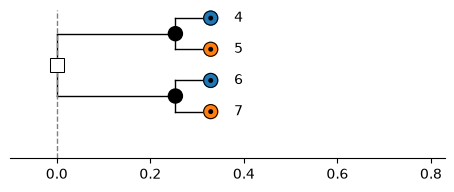

In [4]:
### Tree Generation

speciesTree, geneTree = MISC_Functions.generateTree(seed =43, nSpecies = 2)
# Gute Kombinationen:
# (43,2), (1,5)
# get color dicts
species_colors, gene_colors = assign_colors(speciesTree, geneTree)
# visualize asymetree tree

if not nx.utils.graphs_equal(BMG, BMGBC):
    print("the BMG already breaks for the Tree")


visualize(geneTree, color_dict=gene_colors)

# convert to networkx
Tree = convert_to_nx(geneTree)

# Original BMG:
BMG = bmg(Tree,mode='weak')
#BMG = thinness_graph(bmg(Tree,mode='weak'))
BC = BICcherry_reverse(BMG)
BMGBC = bmg(BC,mode='weak')

Es konnten 100 Hybride eingefügt werden, bevor die BMGs nicht mehr übereinstimmten
set()


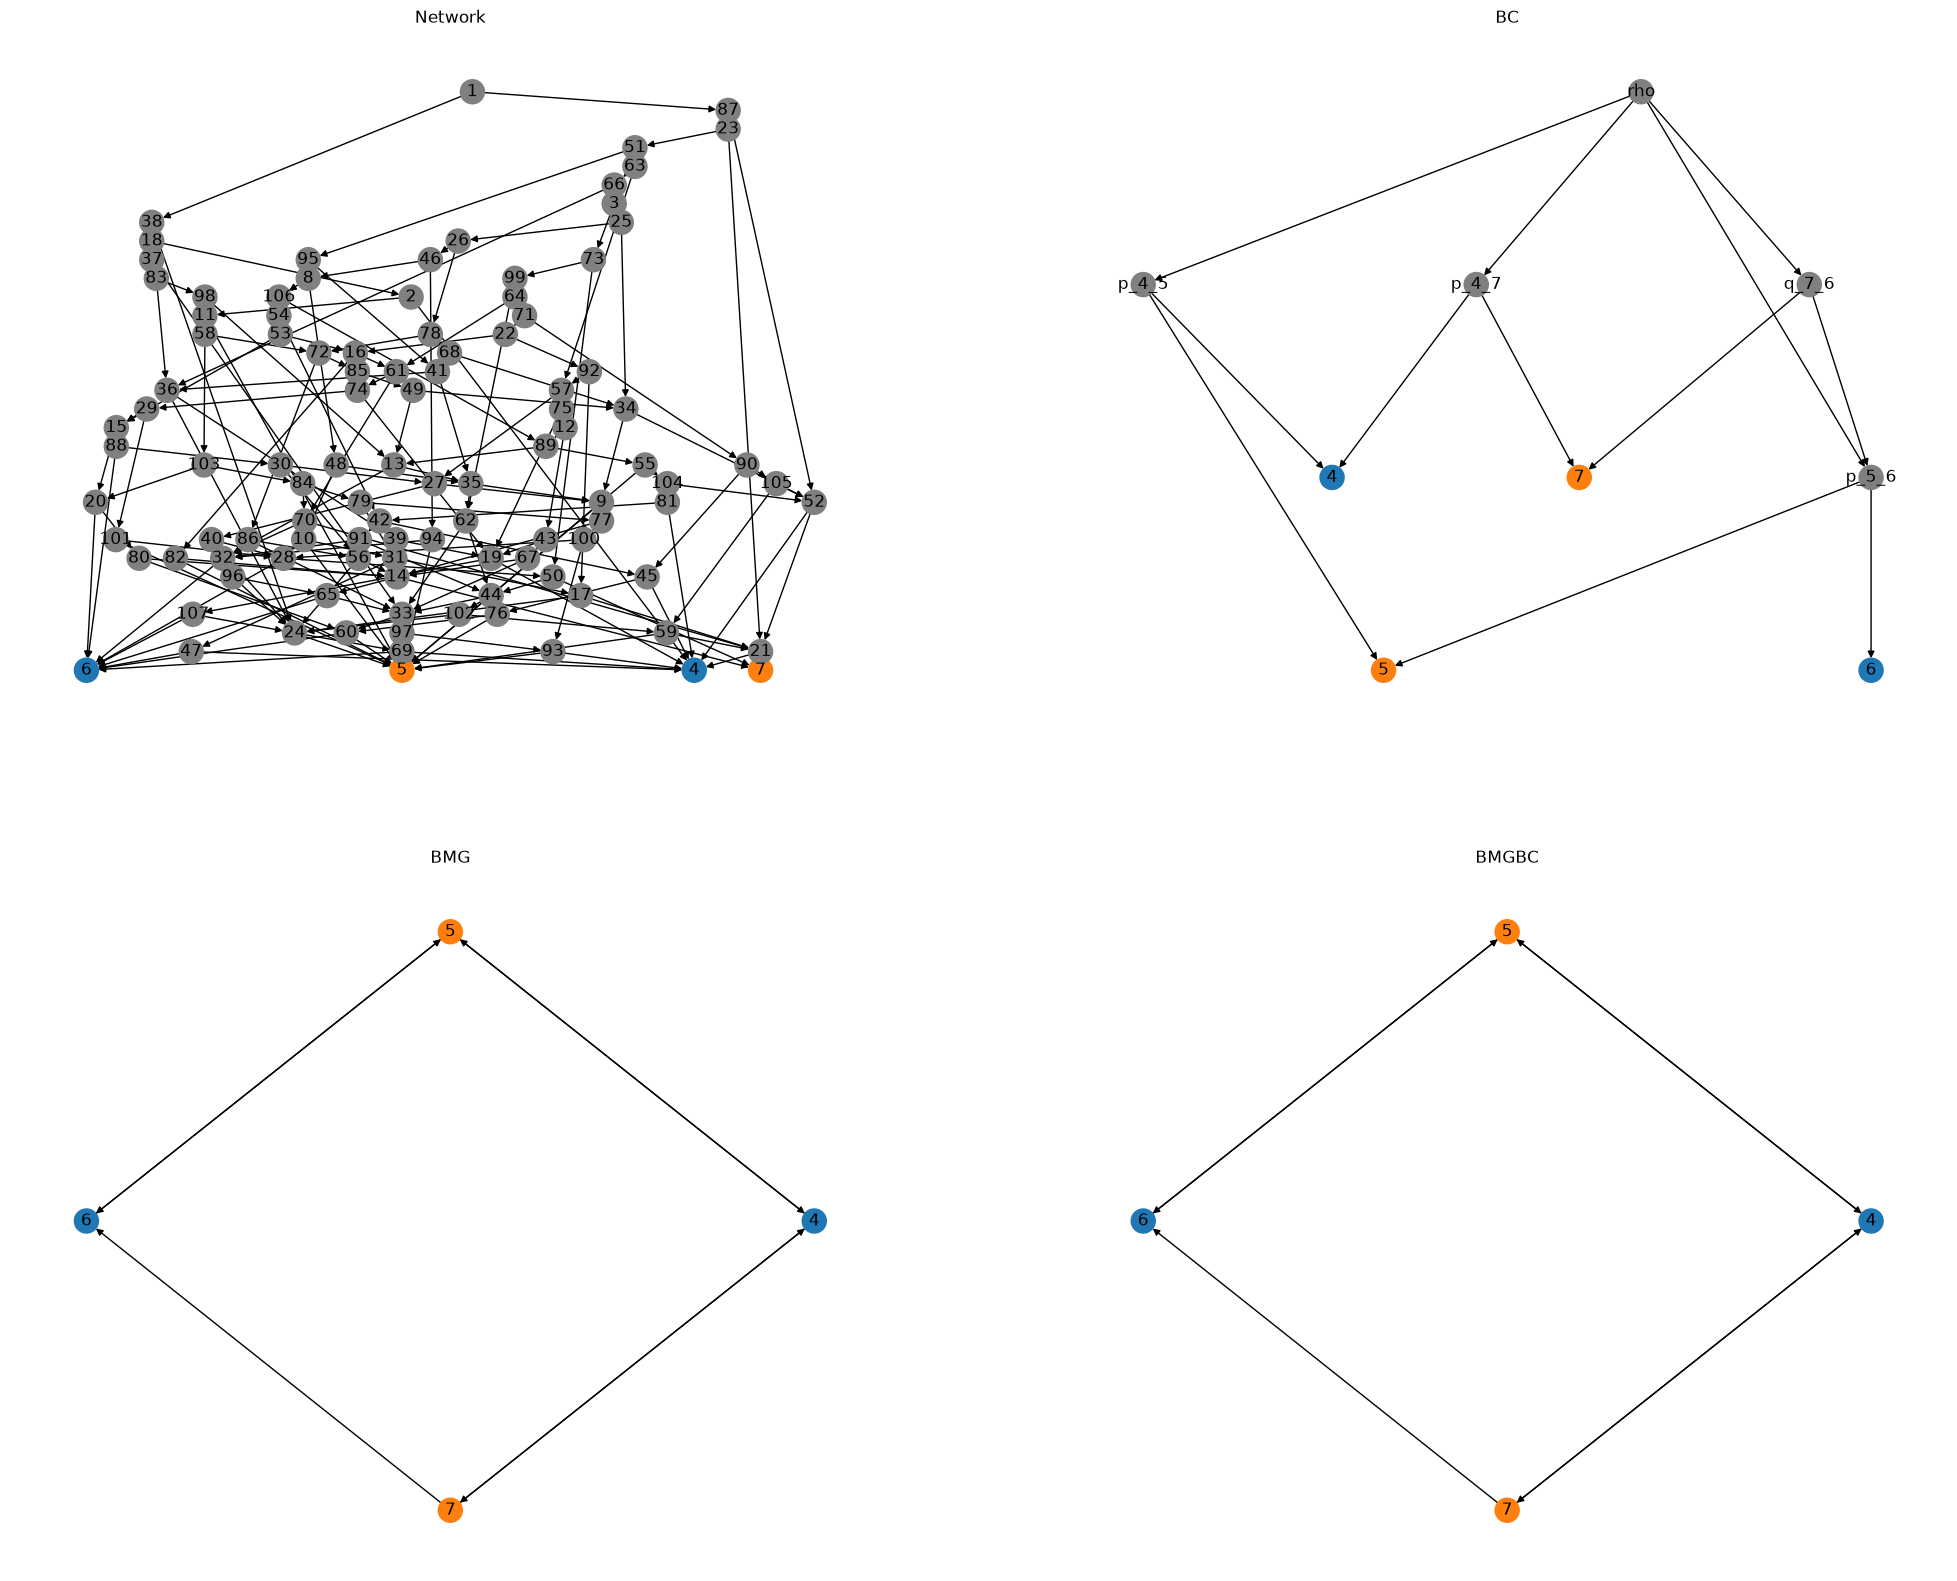

In [5]:
# Testen, wie viele Hybride man einfügen kann, bevor die beiden BMGs nicht mehr übereinstimmen
# random.seed(6)
mode = "weak"
count = 0
Network = copy.deepcopy(Tree)
# gene color dict turn keys to strings
gene_colors_str = {str(k): v for k, v in gene_colors.items()}

#BMG, gene_colors = thinness_graph(bmg(Tree), gene_colors_str)
#BMG = thinness_graph(bmg(Tree))
BMG = bmg(Tree)
# BC = MultiLayerdBICCherry(BMG)
BC = BICcherry_reverse(BMG)
BMGBC = bmg(BC)

while nx.utils.graphs_equal(BMG, BMGBC) and count < 100:
    Network,combinedNodes = insertHybrid2(Network)
    #BMG = thinness_graph(bmg(Network, mode = mode))
    BMG = bmg(Network, mode = mode)
    # BC = MultiLayerdBICCherry(BMG)
    BC = BICcherry_reverse(BMG)
    BMGBC = bmg(BC, mode = mode)
    count += 1
    # if count % 10 == 0:
    #     print("Count = ",count)

    # prüfen, ob der zuletzt generierte Hybrid 2 leaves unterschiedlicher Farbe sind
    # node1 = combinedNodes[0]
    # node2 = combinedNodes[1]

    # if Network.nodes[node1]['color']!=Network.nodes[node2]['color']:
    #     print("Durch den Hybrid wurden zwei Äste unterschiedlicher Farbe direkt verbunden")

    # if Network.nodes[node1]['color']!=Network.nodes[node2]['color'] and Network.out_degree(node1) == 0 and Network.out_degree(node2) == 0:
    #     print("Durch den Hybrid wurden zwei Blätter unterschiedlicher Farbe direkt verbunden")

print("Es konnten",count,"Hybride eingefügt werden, bevor die BMGs nicht mehr übereinstimmten")




# visualize tree and network
fig, axes = plt.subplots(2, 2, figsize=(25, 20))

pos = graphviz_layout(Network, prog="dot")
nodes_list = [v for v in Network.nodes()]
nodes_colors = [gene_colors_str.get(v, "grey") for v in nodes_list]

nx.draw(Network, pos, nodelist=nodes_list, node_color= nodes_colors, with_labels = True, ax=axes[0,0])
axes[0,0].set_title("Network")

pos = graphviz_layout(BC, prog="dot")
nodes_list = [v for v in BC.nodes()]
nodes_colors = [gene_colors_str.get(v, "grey") for v in nodes_list]
nx.draw(BC, pos, nodelist=nodes_list, node_color= nodes_colors, with_labels = True, ax=axes[0,1])
axes[0,1].set_title("BC")


nodes_list = [v for v in BMG.nodes()]
nodes_colors = [gene_colors_str.get(v, "grey") for v in nodes_list]
axes[1,0].set_title("BMG")
nx.draw(BMG, nx.circular_layout(BMG), nodelist=nodes_list, node_color= nodes_colors, ax=axes[1,0], with_labels=True)


nodes_list = [v for v in BMGBC.nodes()]
nodes_colors = [gene_colors_str.get(v, "grey") for v in nodes_list]
axes[1,1].set_title("BMGBC")
nx.draw(BMGBC, nx.circular_layout(BMG), nodelist=nodes_list, node_color= nodes_colors, ax=axes[1,1], with_labels=True)

print(BMG.edges - BMGBC.edges)


# Testing on trees

In [8]:
# generate gene trees
SEED = 2
SPECIES = range(3, 7)
RUNS = 2

seeds = [i+1 for i in range(RUNS)]
# for every run, do the following
for seed in seeds:
    #seed = SEED +1
    current_species = random.Random(seed).choice(SPECIES)
    speciesTree, geneTree = MISC_Functions.generateTree(seed =SEED, nSpecies = current_species)
    
    # turn gene tree into nx
    tree = convert_to_nx(geneTree)
    
    # generate bmg of tree
    BMG = bmg(tree, mode="weak")
    # create thinnes classes for BMG
    thin_BMG = thinness_graph(BMG)
    
    # generate lrt (target)
    lrt = lrt_from_bmg(thin_BMG)
    
    # generate the three networks to test
    cherry_restrict = BICcherryRestrict(thin_BMG)
    cherry_reverse = BICcherry_reverse(thin_BMG, simplify=False)
    cherry_simple = BICcherry_reverse(thin_BMG, simplify=True)
    
    # use Max's function to simply networks
    greedy_restrict, steps_restricted = greedy_search(cherry_restrict, report_step_num=True)
    greedy_reverse, steps_reverse = greedy_search(cherry_reverse, report_step_num=True)
    greedy_simple, steps_simple = greedy_search(cherry_simple, report_step_num=True)
    
    # report if greedy managed to reach lrt
    if nx.is_isomorphic(lrt, greedy_restrict):
        print(f"Restricted returns the correct lrt after {steps_restricted} steps.")
    else:
        print(f"Restricted does NOT return the correct lrt after {steps_restricted} steps.")
    
    if nx.is_isomorphic(lrt, greedy_reverse):
        print(f"Reverse returns the correct lrt after {steps_reverse} steps.")
    else:
        print(f"Reverse does NOT return the correct lrt after {steps_reverse} steps.")
    
    if nx.is_isomorphic(lrt, greedy_simple):
        print(f"Simplified returns the correct lrt after {steps_simple} steps.")
    else:
        print(f"Simplified does NOT return the correct lrt after {steps_simple} steps.")

    # TODO: instead of simply printing the results in the console, I want to collect them for plots and report
    # report: function {name} did return tree correctly {number of correct times} out of {Runs} times with a mean {mean}, min {min} and max {max} number of steps
    # plots: one boxplot for all functions, with one box per function showing the distribution of steps, text above with the number of correct lrt returns

Restricted does NOT return the correct lrt after 76 steps.
Reverse does NOT return the correct lrt after 52 steps.
Simplified does NOT return the correct lrt after 10 steps.
Restricted does NOT return the correct lrt after 23 steps.
Reverse does NOT return the correct lrt after 18 steps.
Simplified returns the correct lrt after 10 steps.


# Figure for Trees

[Parallel(n_jobs=-2)]: Using backend LokyBackend with 13 concurrent workers.
[Parallel(n_jobs=-2)]: Done   2 out of   4 | elapsed:    0.8s remaining:    0.8s


=== LRT-Report ueber 4 Runs ===
Restrict    did return the tree correctly 1 out of 4 times with a mean 38.75, min 20 and max 86 number of steps
Reverse     did return the tree correctly 1 out of 4 times with a mean 22.50, min 18 and max 27 number of steps
Simplified  did return the tree correctly 3 out of 4 times with a mean 17.00, min 10 and max 38 number of steps
Figur gespeichert: /home/julia/Documents/GitProjects/fortgeschrittene_Methoden_der_Bioinformatik/Presentation/figures/lrt_boxplot_runs4_seed2.svg


[Parallel(n_jobs=-2)]: Done   4 out of   4 | elapsed:    3.7s finished


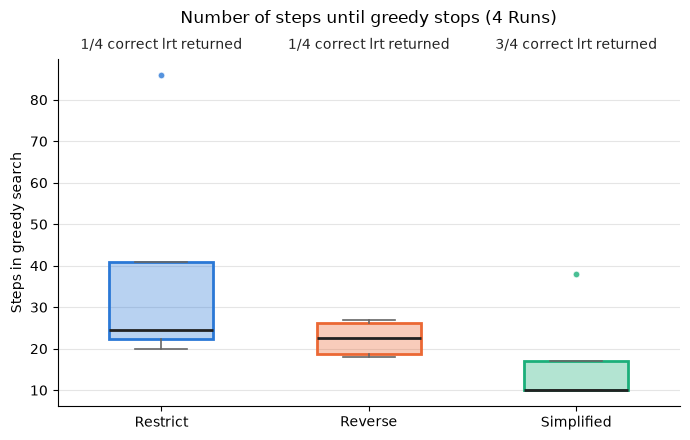

In [9]:
# =====================================================================
# LRT-Experiment: erreichen die drei BIC-Cherry-Netzwerke nach
# greedy_search den korrekten LRT?
#
# Voraussetzung (im Notebook definiert/importiert): MISC_Functions,
# convert_to_nx, bmg, thinness_graph, lrt_from_bmg, BICcherryRestrict,
# BICcherry_reverse, greedy_search
# =====================================================================

import random

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from matplotlib.ticker import MaxNLocator

# Reihenfolge = Reihenfolge im Report und im Plot
FUNCTIONS = ["Restrict", "Reverse", "Simplified"]
# feste kategoriale Farben (farbfehlsichtigkeits-geprueft), eine pro Funktion
COLORS = {"Restrict": "#2a78d6", "Reverse": "#eb6834", "Simplified": "#1baf7a"}


def _run_one(i, run_seed, n_species):
    """Ein Run (laeuft in einem eigenen Prozess): Baum erzeugen, die drei
    Netzwerke bauen, greedy_search anwenden und mit dem LRT vergleichen.
    Gibt eine Zeile (dict) pro Funktion zurueck."""
    import random
    import traceback

    import networkx as nx
    import numpy as np

    base = {"run": i, "seed": run_seed, "n_species": n_species}
    try:
        speciesTree, geneTree = MISC_Functions.generateTree(seed=run_seed, nSpecies=n_species)
        tree = convert_to_nx(geneTree)

        # reproduzierbar, falls greedy_search o.ae. Zufall benutzt
        random.seed(run_seed)
        np.random.seed(run_seed % 2**32)

        thin_BMG = thinness_graph(bmg(tree, mode="weak"))
        lrt = lrt_from_bmg(thin_BMG)

        networks = {
            "Restrict": lambda: BICcherryRestrict(thin_BMG),
            "Reverse": lambda: BICcherry_reverse(thin_BMG, simplify=False),
            "Simplified": lambda: BICcherry_reverse(thin_BMG, simplify=True),
        }
        rows = []
        for name in FUNCTIONS:
            greedy, steps = greedy_search(networks[name](), report_step_num=True)
            rows.append({**base, "function": name,
                         "correct": nx.is_isomorphic(lrt, greedy),
                         "steps": steps, "error": None})
        return rows
    except Exception:
        # ein kaputter Run soll nicht das ganze Experiment abbrechen
        err = traceback.format_exc(limit=3)
        return [{**base, "function": name, "correct": False, "steps": None, "error": err}
                for name in FUNCTIONS]


def run_lrt_experiment(runs=10, seed=2, species=range(3, 7), n_jobs=-2, verbose=5):
    """Fuehrt alle Runs parallel aus (joblib). Run i benutzt den Seed
    seed + i; die Spezies-Anzahl wird mit genau diesem Seed aus `species`
    gezogen. Gibt eine Liste von Zeilen (eine pro Run und Funktion) zurueck."""
    from joblib import Parallel, delayed

    species = list(species)
    plan = [(i, seed + i, random.Random(seed + i).choice(species)) for i in range(runs)]
    results = Parallel(n_jobs=n_jobs, verbose=verbose)(
        delayed(_run_one)(i, s, n) for i, s, n in plan
    )
    return [row for rows in results for row in rows]


def print_lrt_report(rows):
    runs = len({r["run"] for r in rows})
    print(f"=== LRT-Report ueber {runs} Runs ===")
    for name in FUNCTIONS:
        mine = [r for r in rows if r["function"] == name]
        ok = [r for r in mine if r["error"] is None]
        n_correct = sum(r["correct"] for r in ok)
        steps = np.array([r["steps"] for r in ok], dtype=float)
        line = f"{name:<11} did return the tree correctly {n_correct} out of {runs} times"
        if len(steps):
            line += (f" with a mean {steps.mean():.2f}, min {int(steps.min())} "
                     f"and max {int(steps.max())} number of steps")
        print(line)
    errors = sorted({r["run"] for r in rows if r["error"] is not None})
    if errors:
        print(f"\n{len(errors)} Run(s) mit Fehler (nicht mitgezaehlt): {errors[:10]}"
              + (" ..." if len(errors) > 10 else ""))
        print("Erster Fehler:\n" + next(r["error"] for r in rows if r["error"]))


def plot_lrt_boxplot(rows, title=None, ax=None, save_path=None, dpi=300):
    """Ein Boxplot mit einer Box pro Funktion (Verteilung der Schritte),
    darueber die Anzahl korrekter LRT-Rekonstruktionen.

    save_path : str oder None
        Wenn gesetzt, wird die Figur dort gespeichert. Das Format ergibt
        sich aus der Endung (.png, .pdf, .svg, ...). Fehlende Ordner
        werden angelegt."""
    runs = len({r["run"] for r in rows})
    data, labels = [], []
    for name in FUNCTIONS:
        data.append([r["steps"] for r in rows if r["function"] == name and r["error"] is None])
        labels.append(name)

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 4.5))
    bp = ax.boxplot(data, patch_artist=True, widths=0.5, showfliers=True,
                    medianprops=dict(color="#222222", linewidth=2),
                    whiskerprops=dict(color="#666666", linewidth=1.2),
                    capprops=dict(color="#666666", linewidth=1.2))
    ax.set_xticks(range(1, len(labels) + 1), labels)
    for patch, flier, name in zip(bp["boxes"], bp["fliers"], FUNCTIONS):
        patch.set_facecolor(COLORS[name] + "55")      # heller Fill
        patch.set_edgecolor(COLORS[name])
        patch.set_linewidth(2)
        flier.set(marker="o", markersize=5, markerfacecolor=COLORS[name],
                  markeredgecolor="white", alpha=0.8)

    # Anzahl korrekter LRTs ueber jeder Box (in Textfarbe, nicht Serienfarbe)
    for x, name in enumerate(FUNCTIONS, start=1):
        n_correct = sum(r["correct"] for r in rows
                        if r["function"] == name and r["error"] is None)
        ax.text(x, 1.02, f"{n_correct}/{runs} correct lrt returned",
                transform=ax.get_xaxis_transform(), ha="center", va="bottom",
                fontsize=10, color="#222222")

    ax.set_ylabel("Steps in greedy search")
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(axis="y", color="#e5e5e5", linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.set_title(title or f"Number of steps until greedy stops ({runs} Runs)", pad=26)
    fig = ax.figure
    fig.tight_layout()
    if save_path is not None:
        import os
        folder = os.path.dirname(save_path)
        if folder:
            os.makedirs(folder, exist_ok=True)
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"Figur gespeichert: {os.path.abspath(save_path)}")
    return ax


# =====================================================================
# Ausfuehrung
# =====================================================================
if __name__ == "__main__":
    SEED = 2                # Run i benutzt Seed SEED + i
    SPECIES = range(3, 7)   # Spezies-Anzahl pro Run: zufaellig aus 3..6
    RUNS = 4

    rows = run_lrt_experiment(runs=RUNS, seed=SEED, species=SPECIES,
                              n_jobs=-2)  # -1 = alle Kerne, 1 = sequentiell
    print_lrt_report(rows)
    # speichern (vor plt.show(), danach ist die Figur ggf. leer)
    plot_lrt_boxplot(rows, save_path=f"../Presentation/figures/lrt_boxplot_runs{RUNS}_seed{SEED}.svg")
    plt.show()

# Figure for Networks

In [6]:
# =====================================================================
# Netzwerk-Experiment: liefern die drei BIC-Cherry-Netzwerke nach
# greedy_search noch das urspruengliche (thin) BMG, und wie stark wurde
# das Netzwerk dabei vereinfacht?
#
# Voraussetzung (im Notebook definiert/importiert): MISC_Functions,
# convert_to_nx, bmg, thinness_graph, insertHybrid2, BICcherryRestrict,
# BICcherry_reverse, greedy_search
# =====================================================================

import random

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from matplotlib.ticker import MaxNLocator

# Reihenfolge = Reihenfolge im Report und im Plot
FUNCTIONS = ["Restrict", "Reverse", "Simplified"]
# feste kategoriale Farben (farbfehlsichtigkeits-geprueft), eine pro Funktion
COLORS = {"Restrict": "#2a78d6", "Reverse": "#eb6834", "Simplified": "#1baf7a"}


def _run_one(i, run_seed, n_species, num_hybrids):
    """Ein Run (laeuft in einem eigenen Prozess): Baum erzeugen, die drei
    Netzwerke bauen, greedy_search anwenden und mit dem LRT vergleichen.
    Gibt eine Zeile (dict) pro Funktion zurueck."""
    import random
    import traceback

    import networkx as nx
    import numpy as np

    base = {"run": i, "seed": run_seed, "n_species": n_species}
    try:
        speciesTree, geneTree = MISC_Functions.generateTree(seed=run_seed, nSpecies=n_species)
        tree = convert_to_nx(geneTree)

        # reproduzierbar, falls greedy_search o.ae. Zufall benutzt
        random.seed(run_seed)
        np.random.seed(run_seed % 2**32)

        # creating hybrid network
        net, combinedNodes = insertHybrid2(tree, i=num_hybrids)
        
        thin_BMG = thinness_graph(bmg(net, mode="weak"))

        networks = {
            "Restrict": lambda: BICcherryRestrict(thin_BMG),
            "Reverse": lambda: BICcherry_reverse(thin_BMG, simplify=False),
            "Simplified": lambda: BICcherry_reverse(thin_BMG, simplify=True),
        }
        rows = []
        for name in FUNCTIONS:
            greedy, steps = greedy_search(networks[name](), report_step_num=True)
            rows.append({**base, "function": name,
                         "correct": nx.utils.graphs_equal(thin_BMG, bmg(greedy, mode="weak")),
                         "steps": steps, "edges": len(list(greedy.edges()))/len(list(net.edges())), "error": None})
        return rows
    except Exception:
        # ein kaputter Run soll nicht das ganze Experiment abbrechen
        err = traceback.format_exc(limit=3)
        return [{**base, "function": name, "correct": False, "steps": None, "edges": None, "error": err}
                for name in FUNCTIONS]


def run_lrt_experiment(runs=10, seed=2, species=range(3, 7), n_jobs=-2, verbose=5, h=5):
    """Fuehrt alle Runs parallel aus (joblib). Run i benutzt den Seed
    seed + i; die Spezies-Anzahl wird mit genau diesem Seed aus `species`
    gezogen. Gibt eine Liste von Zeilen (eine pro Run und Funktion) zurueck."""
    from joblib import Parallel, delayed

    species = list(species)
    plan = [(i, seed + i, random.Random(seed + i).choice(species), h) for i in range(runs)]
    results = Parallel(n_jobs=n_jobs, verbose=verbose)(
        delayed(_run_one)(i, s, n, h) for i, s, n, h in plan
    )
    return [row for rows in results for row in rows]


def print_lrt_report(rows):
    runs = len({r["run"] for r in rows})
    print(f"=== Netzwerk-Report ueber {runs} Runs ===")
    for name in FUNCTIONS:
        ok = [r for r in rows if r["function"] == name and r["error"] is None]
        n_correct = sum(r["correct"] for r in ok)
        print(f"{name:<11} did return the BMG correctly {n_correct} out of {runs} times")
        if ok:
            steps = np.array([r["steps"] for r in ok], dtype=float)
            edges = np.array([r["edges"] for r in ok], dtype=float)
            print(f"{'':<11}   steps:      mean {steps.mean():.2f}, min {int(steps.min())}, max {int(steps.max())}")
            print(f"{'':<11}   edge ratio: mean {edges.mean():.2f}, min {edges.min():.2f}, max {edges.max():.2f}"
                  f"  (edges after greedy / edges of original network)")
    errors = sorted({r["run"] for r in rows if r["error"] is not None})
    if errors:
        print(f"\n{len(errors)} Run(s) mit Fehler (nicht mitgezaehlt): {errors[:10]}"
              + (" ..." if len(errors) > 10 else ""))
        print("Erster Fehler:\n" + next(r["error"] for r in rows if r["error"]))


def plot_boxplot(rows, metric, ylabel, title, integer=False, reference=None,
                 ax=None, save_path=None, dpi=300):
    """Ein Boxplot mit einer Box pro Funktion fuer den Wert `metric`
    ("steps" oder "edges"), darueber die Anzahl der Runs, in denen das
    urspruengliche BMG korrekt zurueckgegeben wurde.

    integer : bool
        Nur ganzzahlige Ticks auf der y-Achse (fuer Schritte).
    reference : float oder None
        Zeichnet eine gestrichelte Referenzlinie (z.B. 1.0 = gleich viele
        Kanten wie das Ausgangsnetzwerk).
    save_path : str oder None
        Wenn gesetzt, wird die Figur dort gespeichert. Das Format ergibt
        sich aus der Endung (.png, .pdf, .svg, ...). Fehlende Ordner
        werden angelegt."""
    runs = len({r["run"] for r in rows})
    data = [[r[metric] for r in rows if r["function"] == name and r["error"] is None]
            for name in FUNCTIONS]

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 4.5))
    bp = ax.boxplot(data, patch_artist=True, widths=0.5, showfliers=True,
                    medianprops=dict(color="#222222", linewidth=2),
                    whiskerprops=dict(color="#666666", linewidth=1.2),
                    capprops=dict(color="#666666", linewidth=1.2))
    ax.set_xticks(range(1, len(FUNCTIONS) + 1), FUNCTIONS)
    for patch, flier, name in zip(bp["boxes"], bp["fliers"], FUNCTIONS):
        patch.set_facecolor(COLORS[name] + "55")      # heller Fill
        patch.set_edgecolor(COLORS[name])
        patch.set_linewidth(2)
        flier.set(marker="o", markersize=5, markerfacecolor=COLORS[name],
                  markeredgecolor="white", alpha=0.8)

    # Anzahl korrekter BMGs ueber jeder Box (in Textfarbe, nicht Serienfarbe)
    for x, name in enumerate(FUNCTIONS, start=1):
        n_correct = sum(r["correct"] for r in rows
                        if r["function"] == name and r["error"] is None)
        ax.text(x, 1.02, f"{n_correct}/{runs} correct BMGs returned",
                transform=ax.get_xaxis_transform(), ha="center", va="bottom",
                fontsize=10, color="#222222")

    if reference is not None:
        ax.axhline(reference, color="#888888", linewidth=1, linestyle="--", zorder=0)

    ax.set_ylabel(ylabel)
    if integer:
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(axis="y", color="#e5e5e5", linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.set_title(title, pad=26)
    fig = ax.figure
    fig.tight_layout()
    if save_path is not None:
        import os
        folder = os.path.dirname(save_path)
        if folder:
            os.makedirs(folder, exist_ok=True)
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"Figur gespeichert: {os.path.abspath(save_path)}")
    return ax


def plot_steps_boxplot(rows, save_path=None, **kwargs):
    """Figur 1: Anzahl Schritte von greedy_search pro Funktion."""
    runs = len({r["run"] for r in rows})
    return plot_boxplot(rows, "steps", "Steps of greedy search",
                        f"Steps until greedy search stops ({runs} runs)",
                        integer=True, save_path=save_path, **kwargs)


def plot_edges_boxplot(rows, save_path=None, **kwargs):
    """Figur 2: verbleibende Kanten nach greedy_search, relativ zum
    Ausgangsnetzwerk (1.0 = gleich viele Kanten wie das Original)."""
    runs = len({r["run"] for r in rows})
    return plot_boxplot(rows, "edges", "Edges after greedy / edges of original network",
                        f"Remaining edges after greedy search ({runs} runs)",
                        reference=1.0, save_path=save_path, **kwargs)


# =====================================================================
# Ausfuehrung
# =====================================================================
if __name__ == "__main__":
    SEED = 2                # Run i benutzt Seed SEED + i
    SPECIES = range(3, 6)   # Spezies-Anzahl pro Run: zufaellig aus 3..6
    RUNS = 10
    HYBRIDS = 5

    rows = run_lrt_experiment(runs=RUNS, seed=SEED, species=SPECIES,
                              n_jobs=-2, h=HYBRIDS)  # -1 = alle Kerne, 1 = sequentiell
    print_lrt_report(rows)
    # speichern (vor plt.show(), danach ist die Figur ggf. leer)
    FIG_DIR = "../Presentation/figures"
    plot_steps_boxplot(rows, save_path=f"{FIG_DIR}/network_steps_runs{RUNS}_seed{SEED}.svg")
    plot_edges_boxplot(rows, save_path=f"{FIG_DIR}/network_edges_runs{RUNS}_seed{SEED}.svg")
    plt.show()

[Parallel(n_jobs=-2)]: Using backend LokyBackend with 13 concurrent workers.
[Parallel(n_jobs=-2)]: Done   3 out of  10 | elapsed:    2.5s remaining:    5.8s
[Parallel(n_jobs=-2)]: Done   6 out of  10 | elapsed:    9.1s remaining:    6.1s


KeyboardInterrupt: 